# **1. Perkenalan Dataset**


Nama Dataset: Fatalities in the Israeli-Palestinian Conflict  
Sumber: Kaggle  
Link: [Klik Disini](https://www.kaggle.com/datasets/willianoliveiragibin/fatalities-in-the-israeli-palestinian)

Dataset ini berisi data korban tewas dalam konflik Israel-Palestina yang dikumpulkan oleh B'Tselem. Data mencakup periode dari 2000 hingga 2023. Terdapat 16 kolom dengan total 11.124 entri.

**Deskripsi Kolom:**
- `name`: Nama korban.
- `date_of_event`: Tanggal kejadian.
- `age`: Usia korban.
- `citizenship`: Kewarganegaraan (Palestinian, Israeli, etc.).
- `event_location`: Lokasi kejadian.
- `event_location_district`: Distrik lokasi kejadian.
- `event_location_region`: Region (West Bank, Gaza Strip, Israel).
- `date_of_death`: Tanggal kematian (biasanya sama dengan date_of_event).
- `gender`: Jenis kelamin (M/F).
- `took_part_in_the_hostilities`: Apakah korban terlibat dalam permusuhan pada saat kejadian (Yes/No/Unknown?).
- `place_of_residence`: Tempat tinggal korban.
- `place_of_residence_district`: Distrik tempat tinggal.
- `type_of_injury`: Jenis luka (gunfire, explosive, etc.).
- `ammunition`: Jenis amunisi yang digunakan (live ammunition, missile, etc.).
- `killed_by`: Pihak yang membunuh (Israeli security forces, Israeli civilians, Other).
- `notes`: Catatan tambahan.

**Target Analisis:**  
Pada proyek ini, target yang akan diprediksi adalah `took_part_in_the_hostilities` (apakah korban terlibat permusuhan). Ini merupakan permasalahan klasifikasi biner yang bertujuan untuk mengidentifikasi faktor-faktor yang mempengaruhi partisipasi dalam permusuhan.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import glob
import zipfile
from google.colab import files
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"faizfajar28","key":"68b62276592b6d4f7f90e6ea67b8a769"}'}

In [3]:
!ls -lha kaggle.json
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!pwd

-rw-r--r-- 1 root root 67 Mar 30 12:33 kaggle.json
/content


In [4]:
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download willianoliveiragibin/fatalities-in-the-israeli-palestinian

Dataset URL: https://www.kaggle.com/datasets/willianoliveiragibin/fatalities-in-the-israeli-palestinian
License(s): CC0-1.0
100% 463k/463k [00:00<00:00, 78.1MB/s]



In [6]:
zip_file_name = 'fatalities-in-the-israeli-palestinian.zip'

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset_folder') # Extract to a new folder named 'dataset_folder'

# remove the zip file after extraction
os.remove(zip_file_name)

In [7]:
csv_files = glob.glob('/content/dataset_folder/*.csv')

if csv_files:
    df = pd.read_csv(csv_files[0])
    print("Data berhasil dimuat.")
else:
    print("Tidak ditemukan file CSV di dalam folder /content/dataset_folder")

Data berhasil dimuat.


In [8]:
df.head().T

,0,1,2,3,4
name,'Abd a-Rahman Suleiman Muhammad Abu Daghash,Usayed Farhan Muhammad 'Ali Abu 'Ali,'Abdallah 'Imad Sa'ed Abu Hassan,Durgham Muhammad Yihya al-Akhras,Raafat 'Omar Ahmad Khamaisah
date_of_event,2023-09-24,2023-09-24,2023-09-22,2023-09-20,2023-09-19
age,32.0,21.0,16.0,19.0,15.0
citizenship,Palestinian,Palestinian,Palestinian,Palestinian,Palestinian
event_location,Nur Shams R.C.,Nur Shams R.C.,Kfar Dan,'Aqbat Jaber R.C.,Jenin R.C.
event_location_district,Tulkarm,Tulkarm,Jenin,Jericho,Jenin
event_location_region,West Bank,West Bank,West Bank,West Bank,West Bank
date_of_death,2023-09-24,2023-09-24,2023-09-22,2023-09-20,2023-09-19
gender,M,M,M,M,M
took_part_in_the_hostilities,NaN,NaN,NaN,NaN,NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11124 entries, 0 to 11123
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name                          11124 non-null  object 
 1   date_of_event                 11124 non-null  object 
 2   age                           10995 non-null  float64
 3   citizenship                   11124 non-null  object 
 4   event_location                11124 non-null  object 
 5   event_location_district       11124 non-null  object 
 6   event_location_region         11124 non-null  object 
 7   date_of_death                 11124 non-null  object 
 8   gender                        11104 non-null  object 
 9   took_part_in_the_hostilities  9694 non-null   object 
 10  place_of_residence            11056 non-null  object 
 11  place_of_residence_district   11056 non-null  object 
 12  type_of_injury                10833 non-null  object 
 13  a

In [10]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,11124,11083,Name unknown to B'Tselem,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_of_event,11124,2405,2008-12-27,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,10995.0,NaN,NaN,NaN,26.745703,13.780548,1.0,19.0,23.0,31.0,112.0
citizenship,11124,4,Palestinian,10092,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_location,11124,494,Gaza City,2232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_location_district,11124,20,Gaza,2435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_location_region,11124,3,Gaza Strip,7733,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_of_death,11124,2593,2008-12-27,341,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,11104,2,M,9681,NaN,NaN,NaN,NaN,NaN,NaN,NaN
took_part_in_the_hostilities,9694,5,No,4653,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [11]:
# Set style visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

## 4.1. Visualisasi missing values

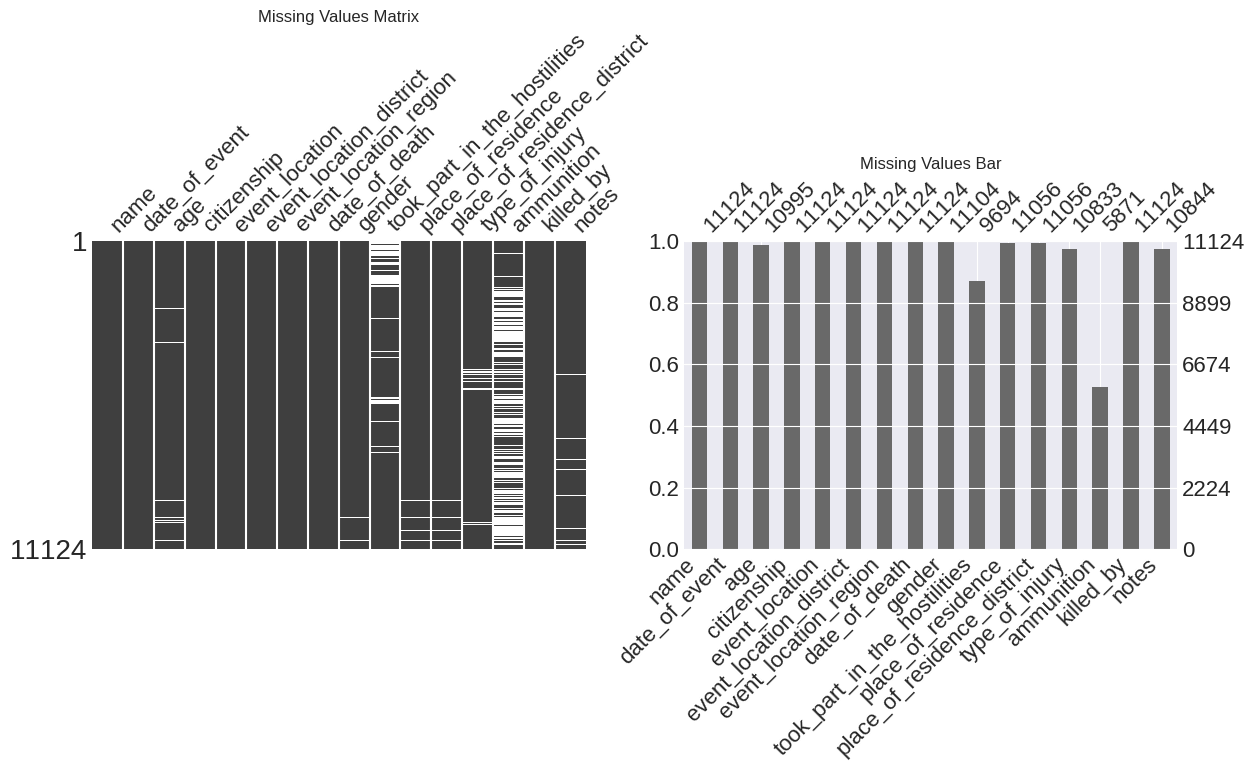

Kolom dengan missing values terbanyak:
ammunition                      5253
took_part_in_the_hostilities    1430
type_of_injury                   291
notes                            280
age                              129
place_of_residence                68
place_of_residence_district       68
gender                            20
date_of_death                      0
event_location_region              0
dtype: int64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
msno.matrix(df, ax=axes[0], sparkline=False)
axes[0].set_title('Missing Values Matrix')
msno.bar(df, ax=axes[1])
axes[1].set_title('Missing Values Bar')
plt.tight_layout()
plt.show()

print("Kolom dengan missing values terbanyak:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

**Insight:** Kolom `ammunition` dan `took_part_in_the_hostilities` memiliki missing value tinggi. Hal ini perlu ditangani pada preprocessing.

## 4.2. Distribusi target (took_part_in_the_hostilities)

Distribusi target (before handling missing):
took_part_in_the_hostilities
No                            4653
Yes                           3467
NaN                           1430
Israelis                       771
Unknown                        603
Object of targeted killing     200
Name: count, dtype: int64

Persentase:
took_part_in_the_hostilities
No                            41.828479
Yes                           31.166846
NaN                           12.855088
Israelis                       6.930960
Unknown                        5.420712
Object of targeted killing     1.797914
Name: proportion, dtype: float64


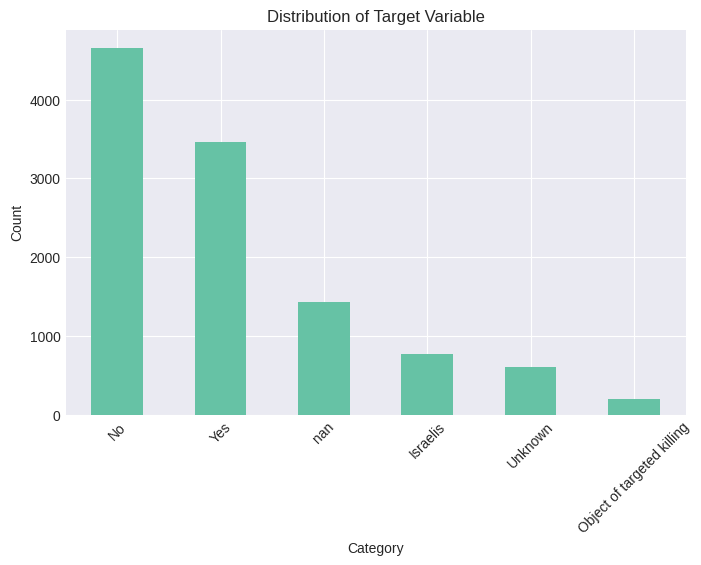

In [13]:
target = 'took_part_in_the_hostilities'

# Menampilkan distribusi sebelum handling missing
print("Distribusi target (before handling missing):")
print(df[target].value_counts(dropna=False))
print("\nPersentase:")
print(df[target].value_counts(dropna=False, normalize=True) * 100)

# Visualisasi distribusi
plt.figure(figsize=(8, 5))
df[target].value_counts(dropna=False).plot(kind='bar')
plt.title('Distribution of Target Variable')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**Insight:** Target memiliki 6 kategori termasuk missing. Mayoritas adalah "No" dan "Yes". Missing cukup besar (~12.8%). Kita perlu memutuskan apakah akan mengisi missing atau hanya menggunakan data yang tidak missing.

## 4.3. Analisis univariat fitur numerik (age)

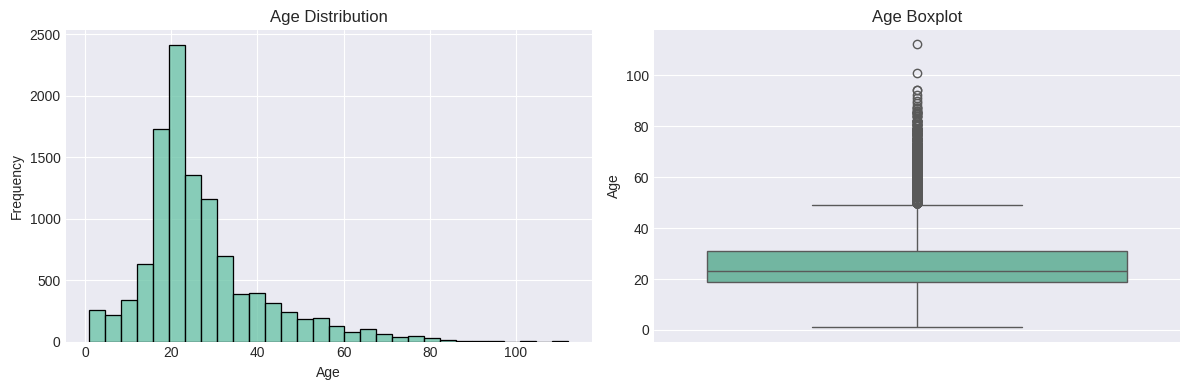

Statistik deskriptif age:
count    10995.000000
mean        26.745703
std         13.780548
min          1.000000
25%         19.000000
50%         23.000000
75%         31.000000
max        112.000000
Name: age, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
sns.histplot(df['age'].dropna(), bins=30, ax=axes[0])
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# Boxplot
sns.boxplot(y=df['age'], ax=axes[1])
axes[1].set_title('Age Boxplot')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

print("Statistik deskriptif age:")
print(df['age'].describe())

**Insight:** Usia korban berkisar antara 1 hingga 112 tahun, dengan rata-rata sekitar 26.7 tahun. Sebaran miring ke kanan (skewed right) dengan outlier di atas 80 tahun.

## 4.4. Analisis univariat fitur kategorikal utama

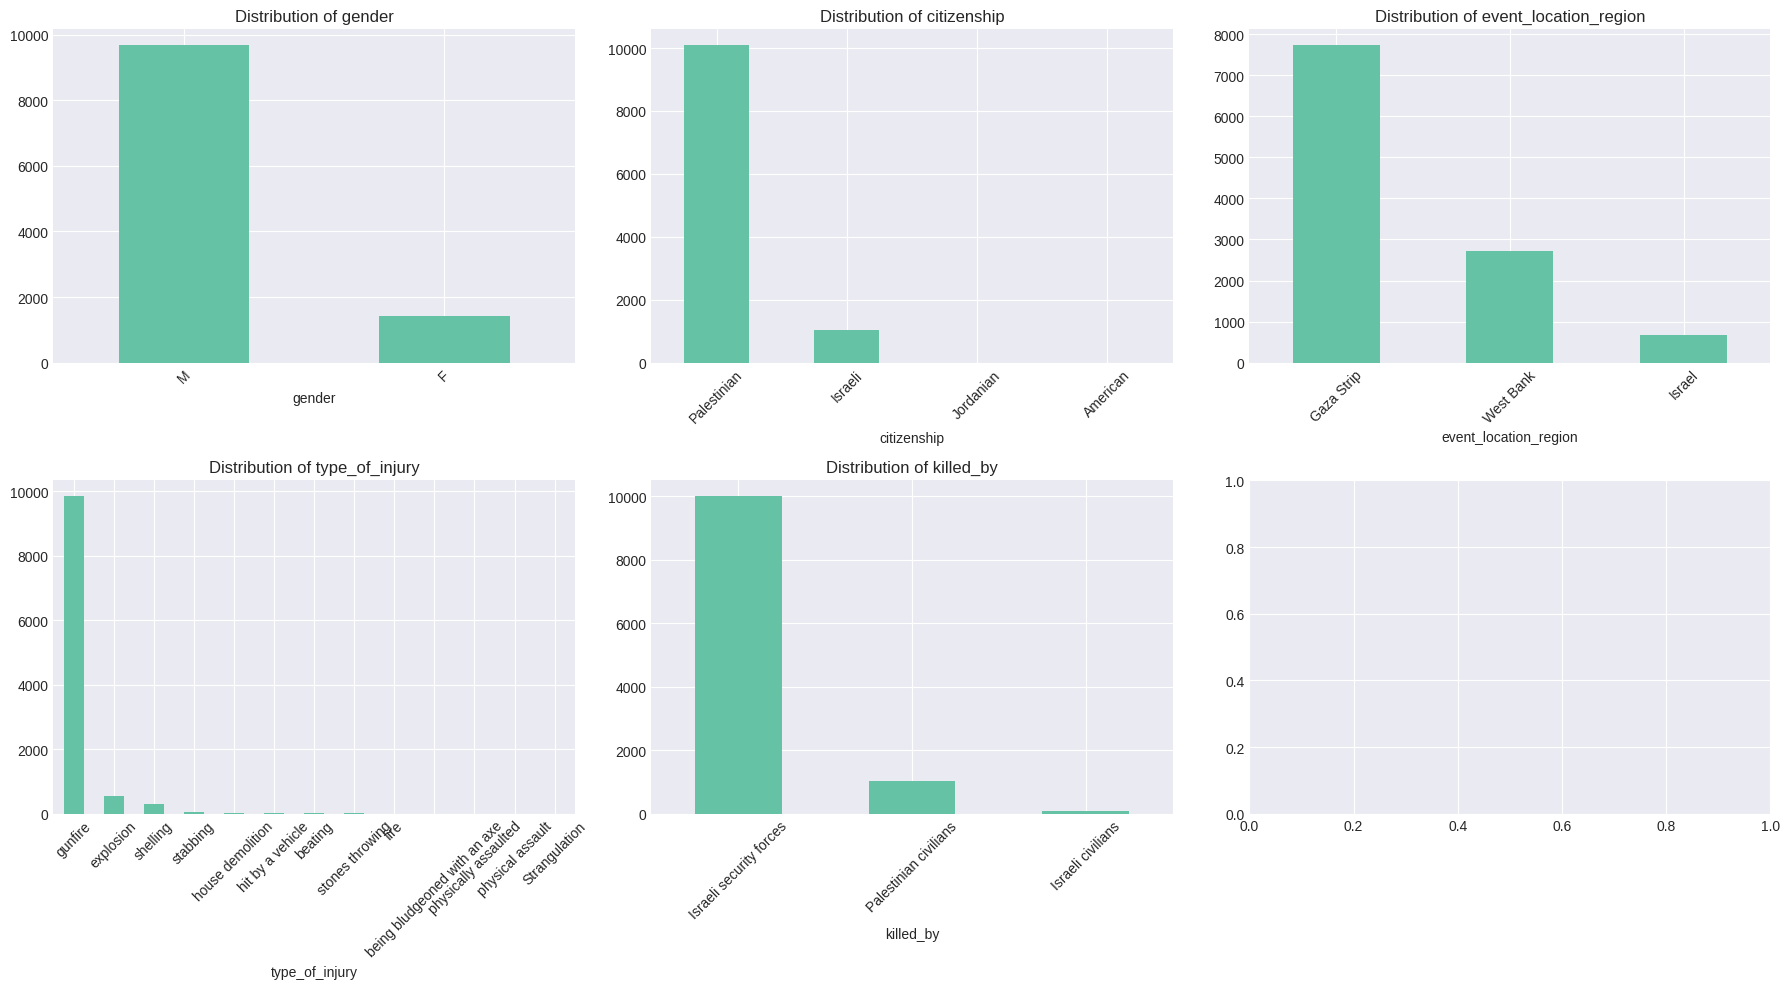

In [15]:
categorical_cols = ['gender', 'citizenship', 'event_location_region', 'type_of_injury', 'killed_by']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Insight:**
- Mayoritas korban adalah laki-laki (M).
- Sebagian besar warga negara Palestina.
- Sebagian besar kejadian di Gaza Strip, diikuti West Bank.
- Jenis luka terbanyak adalah gunfire.
- Pihak yang membunuh didominasi oleh Israeli security forces.

## 4.5. Analisis bivariat dengan target (took_part_in_the_hostilities)

In [16]:
target = 'took_part_in_the_hostilities'
features_to_cross = ['gender', 'citizenship', 'event_location_region', 'type_of_injury', 'killed_by']

for feature in features_to_cross:
    print(f"\n--- Crosstab: {feature} vs {target} ---")
    ct = pd.crosstab(df[feature], df[target], margins=True, normalize='index') * 100
    display(ct)


--- Crosstab: gender vs took_part_in_the_hostilities ---


took_part_in_the_hostilities,Israelis,No,Object of targeted killing,Unknown,Yes
gender,,,,,
F,20.981132,78.641509,0.000000,0.000000,0.377358
M,5.904899,43.250689,2.395496,7.030782,41.418134
All,7.969816,48.097995,2.067397,6.067811,35.796982



--- Crosstab: citizenship vs took_part_in_the_hostilities ---


took_part_in_the_hostilities,Israelis,No,Object of targeted killing,Unknown,Yes
citizenship,,,,,
Israeli,99.870466,0.000000,0.000000,0.000000,0.129534
Jordanian,0.000000,100.000000,0.000000,0.000000,0.000000
Palestinian,0.000000,52.146620,2.241901,6.759332,38.852147
All,7.953373,47.998762,2.063132,6.220342,35.764390



--- Crosstab: event_location_region vs took_part_in_the_hostilities ---


took_part_in_the_hostilities,Israelis,No,Object of targeted killing,Unknown,Yes
event_location_region,,,,,
Gaza Strip,1.723441,53.036219,1.992729,3.904672,39.342938
Israel,81.751825,1.824818,0.000000,1.094891,15.328467
West Bank,11.343805,40.954043,3.025015,17.859220,26.817917
All,7.953373,47.998762,2.063132,6.220342,35.764390



--- Crosstab: type_of_injury vs took_part_in_the_hostilities ---


took_part_in_the_hostilities,Israelis,No,Object of targeted killing,Unknown,Yes
type_of_injury,,,,,
beating,57.142857,28.571429,0.000000,14.285714,0.000000
explosion,90.891089,1.584158,4.554455,0.396040,2.574257
fire,0.000000,100.000000,0.000000,0.000000,0.000000
gunfire,3.266932,50.996016,2.014798,6.203756,37.518497
hit by a vehicle,25.000000,25.000000,0.000000,0.000000,50.000000
house demolition,0.000000,84.000000,0.000000,0.000000,16.000000
shelling,0.000000,66.153846,0.000000,3.076923,30.769231
stabbing,88.888889,11.111111,0.000000,0.000000,0.000000
stones throwing,75.000000,25.000000,0.000000,0.000000,0.000000



--- Crosstab: killed_by vs took_part_in_the_hostilities ---


took_part_in_the_hostilities,Israelis,No,Object of targeted killing,Unknown,Yes
killed_by,,,,,
Israeli civilians,0.000000,57.446809,0.000000,4.255319,38.297872
Israeli security forces,0.000000,52.118071,2.253267,6.771068,38.857594
Palestinian civilians,100.000000,0.000000,0.000000,0.000000,0.000000
All,7.953373,47.998762,2.063132,6.220342,35.764390


**Insight dari crosstab:**
- **Gender:** Laki-laki lebih banyak terlibat dalam permusuhan (41.4%) dibanding perempuan (0.4%).
- **Citizenship:** Hampir semua korban Israel adalah warga Israel, dan mereka tidak terlibat permusuhan.
- **Region:** Di Gaza Strip, persentase terlibat permusuhan lebih tinggi (39.3%) dibanding West Bank (26.8%).
- **Injury Type:** Gunfire memiliki persentase partisipasi tertinggi (37.5%). Explosion dan stabbing lebih banyak dari pihak Israel.
- **Killed by:** Korban yang dibunuh oleh Israeli security forces memiliki persentase partisipasi tertinggi (38.9%).

## 4.6. Analisis tren temporal

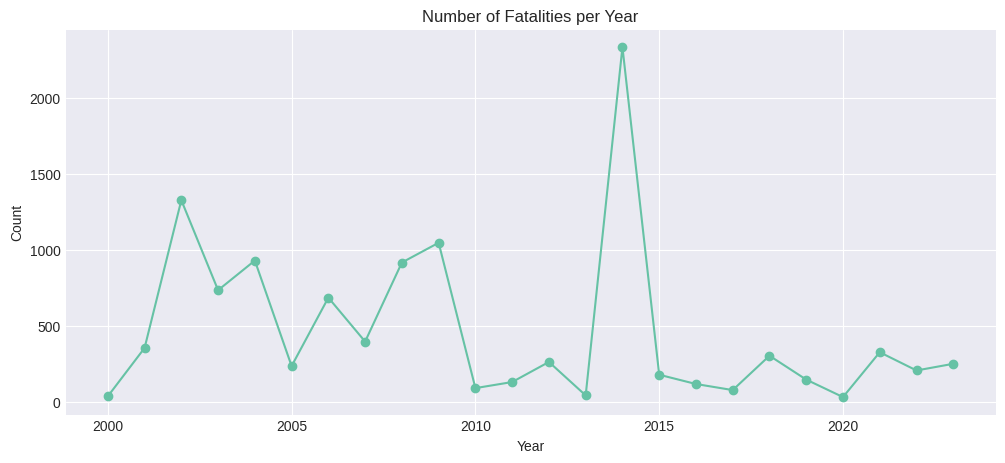

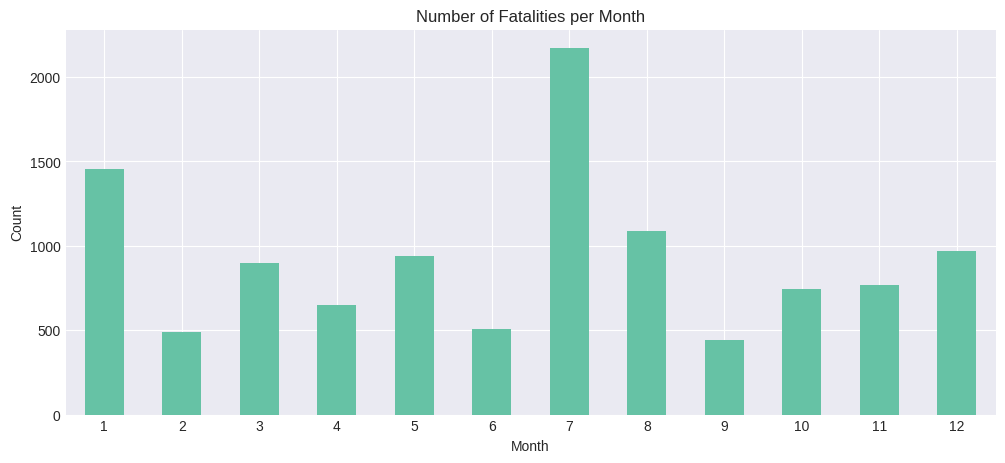

In [17]:
# Konversi date_of_event ke datetime
df['date_of_event'] = pd.to_datetime(df['date_of_event'], errors='coerce')
df['year'] = df['date_of_event'].dt.year
df['month'] = df['date_of_event'].dt.month

# Jumlah kematian per tahun
yearly_counts = df.groupby('year').size()
plt.figure(figsize=(12, 5))
yearly_counts.plot(kind='line', marker='o')
plt.title('Number of Fatalities per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid(True)
plt.show()
print("")
# Jumlah kematian per bulan
monthly_counts = df.groupby('month').size()
plt.figure(figsize=(12, 5))
monthly_counts.plot(kind='bar')
plt.title('Number of Fatalities per Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

**Insight:**
- Lonjakan kematian terjadi pada tahun 2002 (Intifada kedua) dan 2014 (Perang Gaza).
- Bulan dengan kematian tertinggi adalah Januari, Juli, dan Agustus.

## 4.7. Analisis geospasial

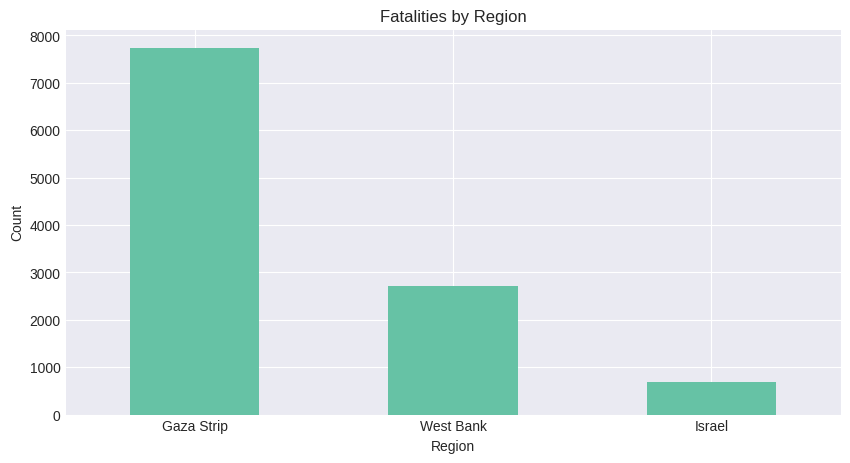

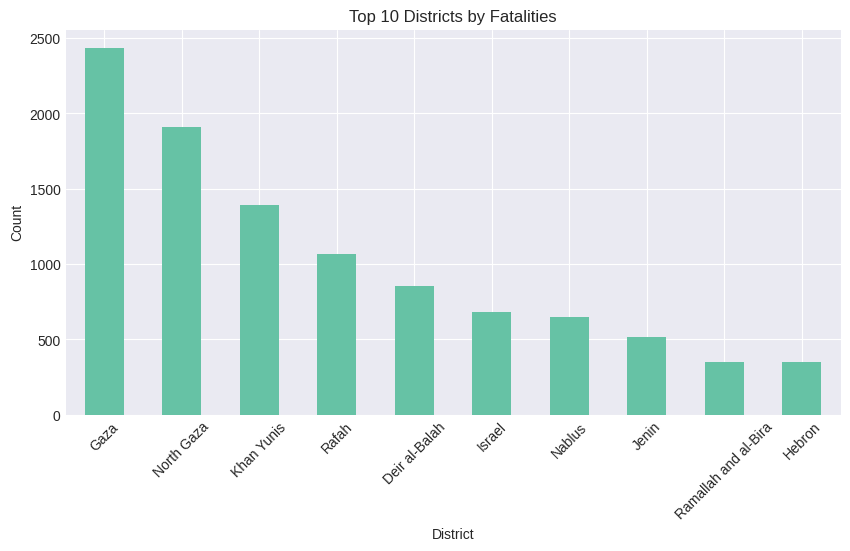

In [18]:
# Distribusi per region
region_counts = df['event_location_region'].value_counts()
plt.figure(figsize=(10, 5))
region_counts.plot(kind='bar')
plt.title('Fatalities by Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()
print("")
# Distribusi per district (top 10)
district_counts = df['event_location_district'].value_counts().head(10)
plt.figure(figsize=(10, 5))
district_counts.plot(kind='bar')
plt.title('Top 10 Districts by Fatalities')
plt.xlabel('District')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**Insight:**
- Wilayah Gaza Strip memiliki korban terbanyak, disusul West Bank.
- Distrik Gaza, North Gaza, dan Khan Yunis adalah lokasi dengan kematian tertinggi, disusul dengan Rafah dan Deir al-Balah.

## 4.8. Partisipasi dalam Permusuhan Berdasarkan Waktu

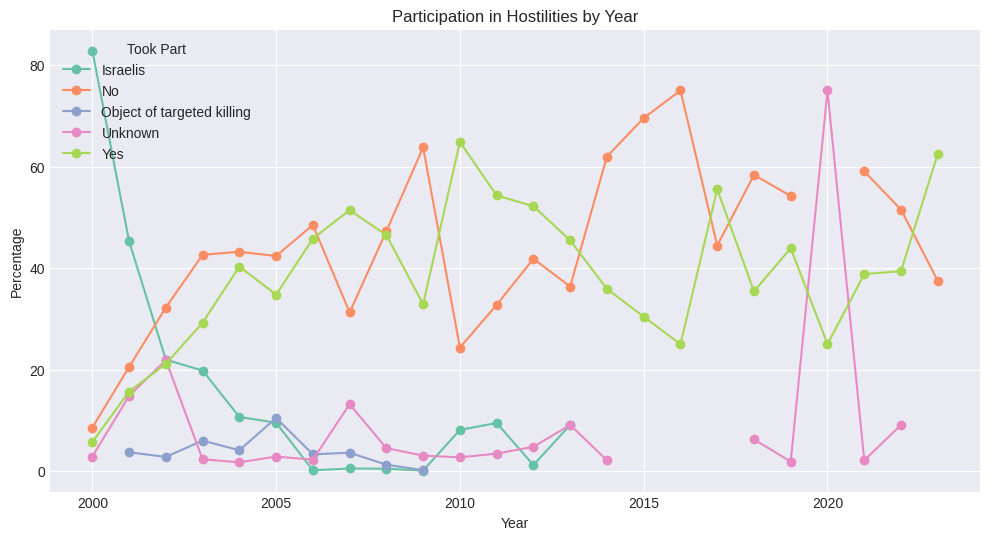

In [19]:
df_part = df[df[target].notna()].copy()
part_by_year = df_part.groupby('year')[target].value_counts(normalize=True).unstack() * 100
part_by_year.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Participation in Hostilities by Year')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.legend(title='Took Part')
plt.grid(True)
plt.show()

**Insight:**
- Pada awal konflik (2000-2004), persentase partisipasi cukup tinggi.
- Setelah 2005, terjadi fluktuasi, dengan peningkatan kembali dan terbanyak pada tahun 2010, 2017 dan 2023.

## 4.9. Analisis jenis luka dan partisipasi

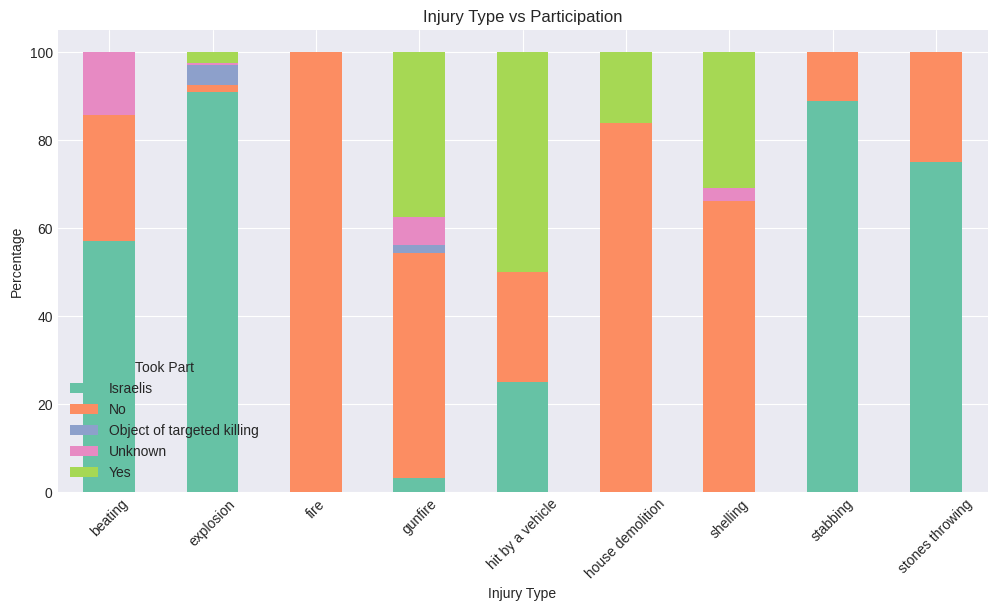

In [20]:
ct_injury_part = pd.crosstab(df['type_of_injury'], df[target], normalize='index') * 100
ct_injury_part.sort_index().plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Injury Type vs Participation')
plt.xlabel('Injury Type')
plt.ylabel('Percentage')
plt.legend(title='Took Part')
plt.xticks(rotation=45)
plt.show()

**Insight:**
- Korban dengan luka tertabrak (hit by vehicle) memiliki kemungkinan terlibat permusuhan tertinggi.
- Luka akibat ledakan (explosion) lebih banyak dialami oleh warga Israel yang tidak terlibat permusuhan dan luka akibat api hampir semuanya dialami oleh warga Palestina yang tidak terlibat permusuhan.

## 4.10. Analisis usia dan partisipasi

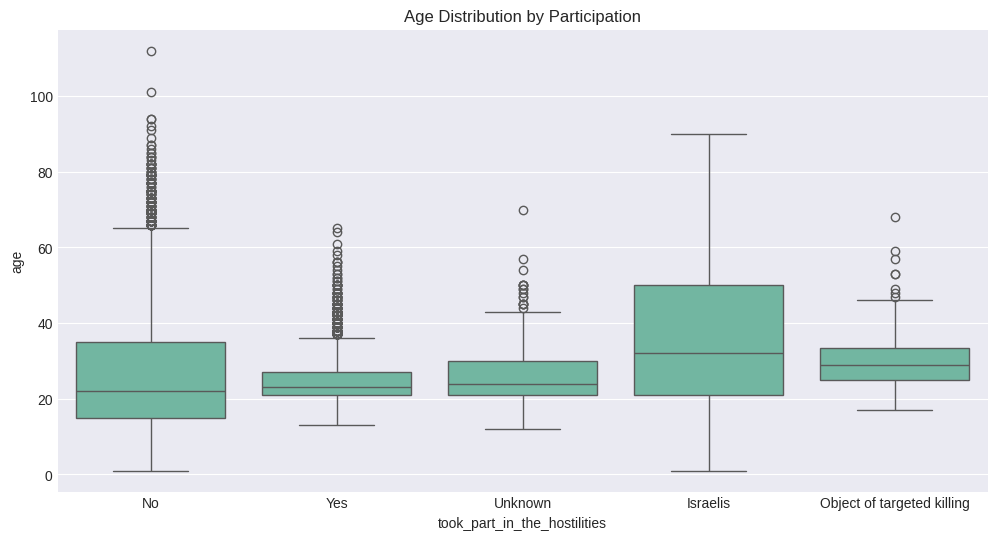

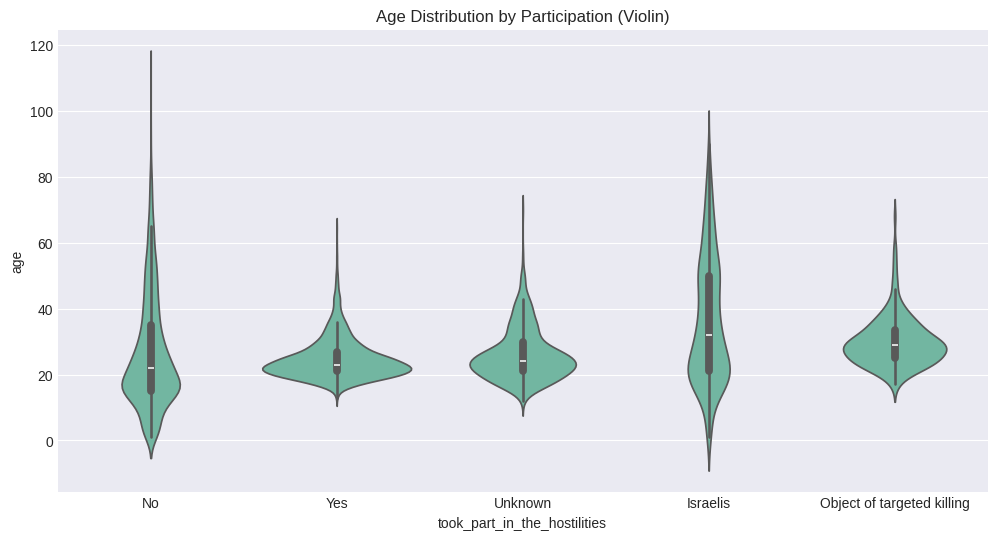

In [21]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=target, y='age', data=df_part)
plt.title('Age Distribution by Participation')
plt.show()
print("")
plt.figure(figsize=(12, 6))
sns.violinplot(x=target, y='age', data=df_part)
plt.title('Age Distribution by Participation (Violin)')
plt.show()

**Insight:**
- Korban yang terlibat permusuhan cenderung lebih muda (median sekitar 20 tahun) dibanding yang tidak terlibat (median sekitar 25 tahun).
- Ada outlier usia tua pada kategori "israelis" dan "No".

# **5. Data Preprocessing**

Pada tahap ini, data akan dibersihkan dan disiapkan untuk model klasifikasi biner.  
**Target:** `took_part_in_the_hostilities`  
- **0** = tidak terlibat permusuhan  
- **1** = terlibat permusuhan  

Semua langkah akan menampilkan kondisi sebelum dan sesudah.

In [22]:
# Persiapan awal
df_prep = df.copy()
print("=== DATA AWAL ===")
print(f"Shape: {df_prep.shape}")
print(f"Kolom: {df_prep.columns.tolist()}\n")

=== DATA AWAL ===
Shape: (11124, 18)
Kolom: ['name', 'date_of_event', 'age', 'citizenship', 'event_location', 'event_location_district', 'event_location_region', 'date_of_death', 'gender', 'took_part_in_the_hostilities', 'place_of_residence', 'place_of_residence_district', 'type_of_injury', 'ammunition', 'killed_by', 'notes', 'year', 'month']



### 5.1 Standarisasi nama kolom
Mengubah semua nama kolom menjadi huruf kecil dan menghapus spasi di awal/akhir.

In [23]:
print("5.1 STANDARISASI NAMA KOLOM")
print("Sebelum:", df_prep.columns.tolist())
df_prep.columns = df_prep.columns.str.strip().str.lower()
print("Sesudah:", df_prep.columns.tolist())
print("-" * 50)

5.1 STANDARISASI NAMA KOLOM
Sebelum: ['name', 'date_of_event', 'age', 'citizenship', 'event_location', 'event_location_district', 'event_location_region', 'date_of_death', 'gender', 'took_part_in_the_hostilities', 'place_of_residence', 'place_of_residence_district', 'type_of_injury', 'ammunition', 'killed_by', 'notes', 'year', 'month']
Sesudah: ['name', 'date_of_event', 'age', 'citizenship', 'event_location', 'event_location_district', 'event_location_region', 'date_of_death', 'gender', 'took_part_in_the_hostilities', 'place_of_residence', 'place_of_residence_district', 'type_of_injury', 'ammunition', 'killed_by', 'notes', 'year', 'month']
--------------------------------------------------


### 5.2 Hapus duplikat
Menghapus baris yang benar-benar identik. Ditemukan 7 baris duplikat.

In [24]:
print("\n5.2 HAPUS DUPLIKAT")
print("Sebelum:", df_prep.shape)
df_prep = df_prep.drop_duplicates()
print("Sesudah:", df_prep.shape)
print(f"Jumlah duplikat dihapus: {11124 - df_prep.shape[0]}")
print("-" * 50)


5.2 HAPUS DUPLIKAT
Sebelum: (11124, 18)
Sesudah: (11117, 18)
Jumlah duplikat dihapus: 7
--------------------------------------------------


### 5.3 Konversi tanggal ke datetime
Mengubah kolom `date_of_event` dan `date_of_death` ke tipe datetime.

In [25]:
df_prep.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11117 entries, 0 to 11123
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   name                          11117 non-null  object        
 1   date_of_event                 11117 non-null  datetime64[ns]
 2   age                           10995 non-null  float64       
 3   citizenship                   11117 non-null  object        
 4   event_location                11117 non-null  object        
 5   event_location_district       11117 non-null  object        
 6   event_location_region         11117 non-null  object        
 7   date_of_death                 11117 non-null  object        
 8   gender                        11103 non-null  object        
 9   took_part_in_the_hostilities  9687 non-null   object        
 10  place_of_residence            11056 non-null  object        
 11  place_of_residence_district   110

In [26]:
print("\n5.3 KONVERSI TANGGAL")
df_prep['date_of_event'] = pd.to_datetime(df_prep['date_of_event'], errors='coerce')
if 'date_of_death' in df_prep.columns:
    df_prep['date_of_death'] = pd.to_datetime(df_prep['date_of_death'], errors='coerce')
print("Kolom tanggal telah dikonversi.")
print("Contoh nilai date_of_event:", df_prep['date_of_event'].iloc[0])
print("-" * 50)


5.3 KONVERSI TANGGAL
Kolom tanggal telah dikonversi.
Contoh nilai date_of_event: 2023-09-24 00:00:00
--------------------------------------------------


In [27]:
df_prep.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11117 entries, 0 to 11123
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   name                          11117 non-null  object        
 1   date_of_event                 11117 non-null  datetime64[ns]
 2   age                           10995 non-null  float64       
 3   citizenship                   11117 non-null  object        
 4   event_location                11117 non-null  object        
 5   event_location_district       11117 non-null  object        
 6   event_location_region         11117 non-null  object        
 7   date_of_death                 11117 non-null  datetime64[ns]
 8   gender                        11103 non-null  object        
 9   took_part_in_the_hostilities  9687 non-null   object        
 10  place_of_residence            11056 non-null  object        
 11  place_of_residence_district   110

### 5.4 Feature engineering dari tanggal
Ekstrak tahun dan bulan dari `date_of_event`. Kolom `death_delay_days` (selisih hari kematian) dibuat tetapi nanti akan dihapus karena tidak informatif (hampir semua 0).

In [28]:
print("\n5.4 FEATURE ENGINEERING DARI TANGGAL")
# Ekstrak fitur temporal
df_prep['event_year'] = df_prep['date_of_event'].dt.year
df_prep['event_month'] = df_prep['date_of_event'].dt.month
# event_dayofweek dihapus karena tidak signifikan
if 'date_of_death' in df_prep.columns:
    df_prep['death_delay_days'] = (df_prep['date_of_death'] - df_prep['date_of_event']).dt.days
    df_prep['death_delay_days'] = df_prep['death_delay_days'].fillna(0).astype(int)

print("Fitur baru ditambahkan: event_year, event_month")
if 'death_delay_days' in df_prep.columns:
    print("  death_delay_days akan dihapus nanti (tidak informatif)")
print("-" * 50)


5.4 FEATURE ENGINEERING DARI TANGGAL
Fitur baru ditambahkan: event_year, event_month
  death_delay_days akan dihapus nanti (tidak informatif)
--------------------------------------------------


### 5.5 Bersihkan target (took_part_in_the_hostilities) menjadi biner 0/1
Mengubah nilai target menjadi 0 (tidak terlibat) dan 1 (terlibat). Kategori lain seperti 'Israelis', 'Unknown', 'Object of targeted killing' dianggap tidak valid (diubah menjadi NaN).

In [29]:
print("\n5.5 BERSIHKAN TARGET")

def normalize_target(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    if x in ['yes', 'y', 'true', '1']:
        return 1
    if x in ['no', 'n', 'false', '0']:
        return 0
    return np.nan

print("Distribusi target sebelum normalisasi:")
print(df_prep['took_part_in_the_hostilities'].value_counts(dropna=False))

df_prep['took_part_in_the_hostilities'] = df_prep['took_part_in_the_hostilities'].apply(normalize_target)

print("\nDistribusi target setelah normalisasi (hanya 0/1 dan NaN):")
print(df_prep['took_part_in_the_hostilities'].value_counts(dropna=False))
print("-" * 50)


5.5 BERSIHKAN TARGET
Distribusi target sebelum normalisasi:
took_part_in_the_hostilities
No                            4653
Yes                           3465
NaN                           1430
Israelis                       771
Unknown                        598
Object of targeted killing     200
Name: count, dtype: int64

Distribusi target setelah normalisasi (hanya 0/1 dan NaN):
took_part_in_the_hostilities
0.0    4653
1.0    3465
NaN    2999
Name: count, dtype: int64
--------------------------------------------------


### 5.6 Filter hanya baris dengan target valid (0 atau 1)
Hanya mempertahankan baris yang memiliki target 0 atau 1.

In [30]:
print("\n5.6 FILTER TARGET BINER")
print("Sebelum filter:", df_prep.shape)
df_prep = df_prep[df_prep['took_part_in_the_hostilities'].isin([0, 1])].copy()
print("Sesudah filter:", df_prep.shape)
print(f"Jumlah baris yang dipertahankan: {df_prep.shape[0]}")
print("-" * 50)


5.6 FILTER TARGET BINER
Sebelum filter: (11117, 21)
Sesudah filter: (8118, 21)
Jumlah baris yang dipertahankan: 8118
--------------------------------------------------


### 5.7 Tangani missing value pada fitur numerik
Kolom `age` memiliki missing value. Diisi dengan median.

In [31]:
print("\n5.7 TANGANI MISSING VALUE NUMERIK")

numeric_cols = ['age']
# death_delay_days akan dihapus nanti, tidak diisi sekarang

print("Missing sebelum imputasi:")
print(df_prep[numeric_cols].isnull().sum())

if 'age' in df_prep.columns:
    df_prep['age'] = pd.to_numeric(df_prep['age'], errors='coerce')
    age_median = df_prep['age'].median()
    df_prep['age'] = df_prep['age'].fillna(age_median)
    print(f"Age diisi dengan median: {age_median:.1f}")

print("\nMissing setelah imputasi:")
print(df_prep[numeric_cols].isnull().sum())
print("-" * 50)


5.7 TANGANI MISSING VALUE NUMERIK
Missing sebelum imputasi:
age    76
dtype: int64
Age diisi dengan median: 23.0

Missing setelah imputasi:
age    0
dtype: int64
--------------------------------------------------


### 5.8 Tangani outlier pada age (clipping)
Usia korban memiliki outlier hingga 112 tahun. Untuk mengurangi efek outlier, kita batasi rentang usia antara 1 dan 90 tahun.

In [32]:
print("\n5.8 TANGANI OUTLIER PADA AGE")
print("Statistik age sebelum clipping:")
print(df_prep['age'].describe())

# Batasi age antara 1 dan 90
df_prep['age'] = df_prep['age'].clip(lower=1, upper=90)

print("\nStatistik age setelah clipping (batas 1-90):")
print(df_prep['age'].describe())
print("-" * 50)


5.8 TANGANI OUTLIER PADA AGE
Statistik age sebelum clipping:
count    8118.000000
mean       25.772974
std        13.553496
min         1.000000
25%        18.000000
50%        23.000000
75%        30.000000
max       112.000000
Name: age, dtype: float64

Statistik age setelah clipping (batas 1-90):
count    8118.000000
mean       25.767554
std        13.524859
min         1.000000
25%        18.000000
50%        23.000000
75%        30.000000
max        90.000000
Name: age, dtype: float64
--------------------------------------------------


### 5.9 Tangani missing value pada fitur kategorikal
Mengisi missing value pada kolom kategorikal dengan 'Unknown'.

In [33]:
print("\n5.9 TANGANI MISSING VALUE KATEGORIKAL")

cat_cols = [
    'gender',
    'citizenship',
    'event_location_region',
    'event_location_district',
    'type_of_injury',
    'killed_by',
    'place_of_residence_district',
    'ammunition'
]

existing_cat_cols = [c for c in cat_cols if c in df_prep.columns]

print("Missing sebelum imputasi (kategorikal):")
for col in existing_cat_cols:
    missing = df_prep[col].isnull().sum()
    if missing > 0:
        print(f"  {col}: {missing} missing")

for col in existing_cat_cols:
    df_prep[col] = df_prep[col].fillna('Unknown').astype(str).str.strip()

print("\nSemua missing kategorikal telah diisi dengan 'Unknown'.")
print("-" * 50)


5.9 TANGANI MISSING VALUE KATEGORIKAL
Missing sebelum imputasi (kategorikal):
  gender: 3 missing
  type_of_injury: 226 missing
  place_of_residence_district: 26 missing
  ammunition: 4180 missing

Semua missing kategorikal telah diisi dengan 'Unknown'.
--------------------------------------------------


### 5.10 Buang kolom yang tidak diperlukan untuk modelling
Menghapus kolom yang tidak relevan, termasuk yang sudah diekstrak atau tidak informatif (`death_delay_days`, `event_dayofweek`).

In [35]:
print("\n5.10 BUANG KOLOM YANG TIDAK DIPERLUKAN")

# Kolom yang akan dihapus
drop_cols = [
    'name',
    'notes',
    'date_of_event',
    'date_of_death',
    'event_location',
    'place_of_residence',
    'year',                     # redundan dengan event_year
    'month',                    # redundan dengan event_month
    'event_dayofweek',          # tidak signifikan
    'death_delay_days'          # hampir semua 0, tidak informatif
]

# Hanya hapus yang ada
drop_cols = [c for c in drop_cols if c in df_prep.columns]
print("Kolom yang akan dihapus:", drop_cols)
df_prep = df_prep.drop(columns=drop_cols)
print("Shape setelah hapus kolom:", df_prep.shape)
print("-" * 50)


5.10 BUANG KOLOM YANG TIDAK DIPERLUKAN
Kolom yang akan dihapus: ['name', 'notes', 'date_of_event', 'date_of_death', 'event_location', 'place_of_residence', 'year', 'month', 'death_delay_days']
Shape setelah hapus kolom: (8118, 12)
--------------------------------------------------


### 5.11 Pisahkan fitur (X) dan target (y)
Memisahkan data menjadi matriks fitur (X) dan vektor target (y).

In [36]:
print("\n5.11 PISAHKAN X (FITUR) DAN y (TARGET)")

target = 'took_part_in_the_hostilities'
X = df_prep.drop(columns=[target])
y = df_prep[target]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("Distribusi y (0=tidak terlibat, 1=terlibat):")
print(y.value_counts())
print("-" * 50)


5.11 PISAHKAN X (FITUR) DAN y (TARGET)
X shape: (8118, 11)
y shape: (8118,)
Distribusi y (0=tidak terlibat, 1=terlibat):
took_part_in_the_hostilities
0.0    4653
1.0    3465
Name: count, dtype: int64
--------------------------------------------------


### 5.12 Split data train-test (80:20, stratify)
Membagi data menjadi training (80%) dan testing (20%) dengan stratifikasi berdasarkan target agar proporsi kelas tetap sama.

In [37]:
print("\n5.12 SPLIT DATA TRAIN-TEST (80:20)")

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print("Distribusi y_train:")
print(y_train.value_counts(normalize=True))
print("Distribusi y_test:")
print(y_test.value_counts(normalize=True))
print("-" * 50)


5.12 SPLIT DATA TRAIN-TEST (80:20)
X_train shape: (6494, 11)
X_test shape: (1624, 11)
Distribusi y_train:
took_part_in_the_hostilities
0.0    0.573144
1.0    0.426856
Name: proportion, dtype: float64
Distribusi y_test:
took_part_in_the_hostilities
0.0    0.573276
1.0    0.426724
Name: proportion, dtype: float64
--------------------------------------------------


### 5.13 OneHotEncoding fitur kategorikal
Menggunakan OneHotEncoder untuk menghindari bias ordinal pada model linear. Encoding dilakukan setelah split untuk mencegah data leakage.

In [39]:
print("\n5.13 ONEHOTENCODING FITUR KATEGORIKAL")

# Identifikasi kolom kategorikal (selain target)
categorical_features = [c for c in existing_cat_cols if c in X_train.columns]
print("Fitur kategorikal yang akan di-encode:", categorical_features)

from sklearn.preprocessing import OneHotEncoder

# Inisialisasi OneHotEncoder (drop='first' untuk menghindari dummy trap)
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Fit pada X_train
ohe.fit(X_train[categorical_features])

# Transform train dan test
X_train_encoded = ohe.transform(X_train[categorical_features])
X_test_encoded = ohe.transform(X_test[categorical_features])

# Konversi ke DataFrame
X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=ohe.get_feature_names_out(categorical_features),
    index=X_train.index
)
X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=ohe.get_feature_names_out(categorical_features),
    index=X_test.index
)

# Hapus kolom kategorikal asli dan gabung dengan hasil encoding
X_train = X_train.drop(columns=categorical_features).join(X_train_encoded_df)
X_test = X_test.drop(columns=categorical_features).join(X_test_encoded_df)

print(f"X_train shape setelah encoding: {X_train.shape}")
print(f"X_test shape setelah encoding: {X_test.shape}")
print("-" * 50)


5.13 ONEHOTENCODING FITUR KATEGORIKAL
Fitur kategorikal yang akan di-encode: ['gender', 'citizenship', 'event_location_region', 'event_location_district', 'type_of_injury', 'killed_by', 'place_of_residence_district', 'ammunition']
X_train shape setelah encoding: (6494, 70)
X_test shape setelah encoding: (1624, 70)
--------------------------------------------------


In [42]:
print("\nCek apakah masih ada object dtype:")
print(X_train.dtypes.value_counts())


Cek apakah masih ada object dtype:
float64    68
int32       2
Name: count, dtype: int64


### 5.14 Scaling fitur numerik (StandardScaler)
Menskalakan fitur numerik (`age`) menggunakan StandardScaler. Scaling juga dilakukan setelah split.

In [40]:
print("\n5.14 SCALING FITUR NUMERIK")

numeric_features = ['age']  # hanya age yang tersisa
numeric_features = [c for c in numeric_features if c in X_train.columns]

if numeric_features:
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
    X_test[numeric_features] = scaler.transform(X_test[numeric_features])
    print(f"Fitur numerik yang di-scale: {numeric_features}")
    print("Contoh hasil scaling (age):")
    print(X_train[['age']].head(3))
else:
    print("Tidak ada fitur numerik untuk di-scale.")

print("-" * 50)


5.14 SCALING FITUR NUMERIK
Fitur numerik yang di-scale: ['age']
Contoh hasil scaling (age):
            age
10130 -0.871432
957   -0.724311
1925   1.188261
--------------------------------------------------


### 5.15 Simpan data dan objek preprocessing untuk digunakan nanti
Menyimpan data train-test dan objek preprocessing (OneHotEncoder, StandardScaler) ke file agar dapat digunakan pada file modelling dan inference.

In [41]:
print("\n5.15 SIMPAN DATA DAN PREPROCESSING OBJECTS")

# Simpan X_train, X_test, y_train, y_test ke CSV
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
print("Data train-test tersimpan sebagai CSV.")

# Simpan encoder dan scaler untuk digunakan di modelling dan inference
import joblib
joblib.dump(ohe, 'onehot_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Objek preprocessing (OneHotEncoder, StandardScaler) tersimpan.")

# Juga simpan dataset final yang sudah diproses (opsional)
df_prep.to_csv('fatalities_preprocessed_final.csv', index=False)
print("Dataset final tersimpan sebagai 'fatalities_preprocessed_final.csv'")

print("\n=== PREPROCESSING SELESAI ===")


5.15 SIMPAN DATA DAN PREPROCESSING OBJECTS
Data train-test tersimpan sebagai CSV.
Objek preprocessing (OneHotEncoder, StandardScaler) tersimpan.
Dataset final tersimpan sebagai 'fatalities_preprocessed_final.csv'

=== PREPROCESSING SELESAI ===
